# DEMO FOR THE BEST NEURAL NETWORK | BY CHRYSANTHI MOUZAKITIS 122450272

In this file I will showcase the various strengths and weaknesses of the best model from the previous file.

All the images used here are new images that are not in the test / training / validation set.

### SETTING THINGS UP

Here I imported some libraries and loaded in the images

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os
from keras.preprocessing.image import load_img, img_to_array, array_to_img
from keras.preprocessing import image_dataset_from_directory
from keras.models import load_model


In [2]:
import os
from google.colab import drive
drive.mount('/content/drive')
base_dir = "./drive/My Drive/AI2"

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [3]:
best_network = load_model(os.path.join(base_dir, "best_network.keras"))

In [4]:
demo_dataset = image_dataset_from_directory(
    directory=os.path.join(base_dir, "examples"), shuffle=False, label_mode=None, image_size=(224, 224))


Found 10 files.


In [5]:
#from https://www.tensorflow.org/tutorials/images/classification learned to change the batch size to read in images 2 at a time
#I will be showing examples in pairs below

batch_dataset = image_dataset_from_directory(
    directory=os.path.join(base_dir, "examples"), shuffle=False, label_mode=None, image_size=(224, 224), batch_size=2)


Found 10 files.


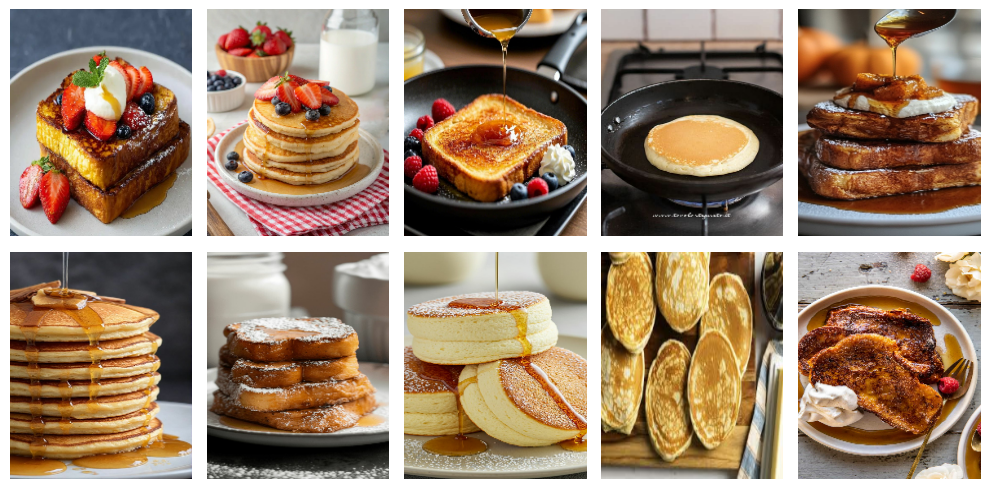

In [6]:
plt.figure(figsize=(10, 5))

for batch in demo_dataset:
    for i, img in enumerate(batch):
        if i >= 10: break
        ax = plt.subplot(2,5, i + 1)
        ax.imshow(img.numpy().astype("uint8"), aspect="auto")
        ax.axis("off")
    break

plt.tight_layout()


These are all 10 images I have selected to show some strengths and weaknesses of the learned model.

## 1) PRESENCE OF BERRIES

In the first two images, we see french toast with berries and pancakes with berries. Throughout this project I made special note of pictures containing berries as they could easily be used as a shortcut if, for example, only the pancake pictures contained berries.

In [7]:
#https://www.tensorflow.org/tutorials/images/classification, showed how to skip over batches and show only selected images
mini_demo_dataset = batch_dataset.skip(0).take(1)

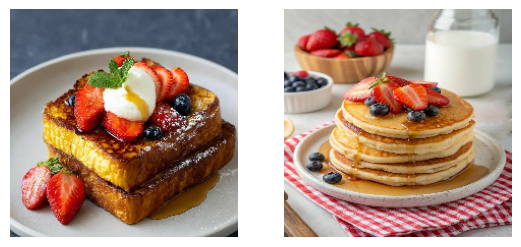

In [8]:
plt.figure(figsize=(10, 6))

for batch in mini_demo_dataset:
    for i, img in enumerate(batch):
        if i >= 2: break
        ax = plt.subplot(1, 3, i + 1)
        ax.imshow(img.numpy().astype("uint8"))
        ax.axis("off")
    break


In [9]:
predictions = best_network.predict(mini_demo_dataset)
for p in predictions:
    if p > 0.5:
        print(f"{p} : Predicted class: Pancake")
    else:
        print(f"{p} : Predicted class: French Toast")

1/1 ━━━━━━━━━━━━━━━━━━━━ 5s 5s/step
[0.01575566] : Predicted class: French Toast
[0.99995744] : Predicted class: Pancake


Here you can see it predicted the classes perfectly with extremely high and low scores for each, meaning it learned other traits such as the thickness and colour of the food and not the presence of berries.

## 2) PRESENCE OF FRYING PAN

Similarily, the presence of  a frying pan is another poteintal shortcut. I will investigate this using two test images

In [10]:
mini_demo_dataset = batch_dataset.skip(1).take(1)

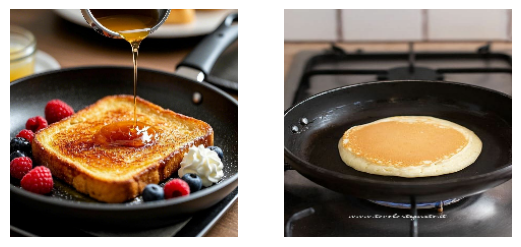

In [11]:
plt.figure(figsize=(10, 6))

for batch in mini_demo_dataset:
    for i, img in enumerate(batch):
        if i >= 2: break
        ax = plt.subplot(1, 3, i + 1)
        ax.imshow(img.numpy().astype("uint8"))
        ax.axis("off")
    break


In [12]:
predictions = best_network.predict(mini_demo_dataset)
for p in predictions:
    if p > 0.5:
        print(f"{p} : Predicted class: Pancake")
    else:
        print(f"{p} : Predicted class: French Toast")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 89ms/step
[0.02363622] : Predicted class: French Toast
[0.5588015] : Predicted class: Pancake


The model was still able to correctly identify the french toast and the pancake, showing it did not use the frying pan as a shortcut. I will note however it is not as strong in classifying the pancake with a final output of 0.55.

## 3) POURING OF SYRUP

Many images also showed the pouring of syrup, I will now investigate if this is a learned shortcut by comparing an image of syrup and french toast and an image of syrup and pancakes. If many of the pancake and syrup images ended up in the training set comapred to the french toast and syrup images, it could lead to the model learning that syrup is associated with pancakes.

In [13]:
mini_demo_dataset = batch_dataset.skip(2).take(1)

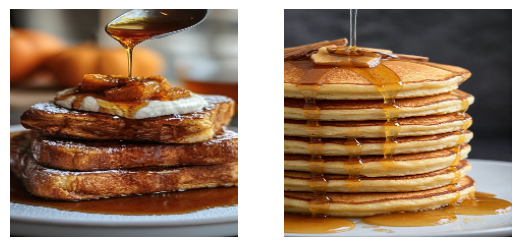

In [14]:
plt.figure(figsize=(10, 6))

for batch in mini_demo_dataset:
    for i, img in enumerate(batch):
        if i >= 2: break
        ax = plt.subplot(1, 3, i + 1)
        ax.imshow(img.numpy().astype("uint8"))
        ax.axis("off")
    break


In [15]:
predictions = best_network.predict(mini_demo_dataset)
for p in predictions:
    if p > 0.5:
        print(f"{p} : Predicted class: Pancake")
    else:
        print(f"{p} : Predicted class: French Toast")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 108ms/step
[0.01059933] : Predicted class: French Toast
[0.9999318] : Predicted class: Pancake


Syrup does not affect classification! This is perfect as it has not learned a shortcut of syrup

## 4) THICK PANCAKES VS THIN FRENCH TOAST

I will now try the most difficult example! French toast is usually classified by its thick width and pancakes by their thinner appearance. I will try thicker pancakes and some more flat appearing french toast to test the model.

In [16]:
mini_demo_dataset = batch_dataset.skip(3).take(1)

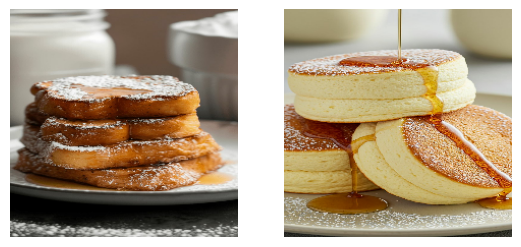

In [17]:
plt.figure(figsize=(10, 6))

for batch in mini_demo_dataset:
    for i, img in enumerate(batch):
        if i >= 2: break
        ax = plt.subplot(1, 3, i + 1)
        ax.imshow(img.numpy().astype("uint8"))
        ax.axis("off")
    break


In [18]:
predictions = best_network.predict(mini_demo_dataset)
for p in predictions:
    if p > 0.5:
        print(f"{p} : Predicted class: Pancake")
    else:
        print(f"{p} : Predicted class: French Toast")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 126ms/step
[0.66380525] : Predicted class: Pancake
[0.26851705] : Predicted class: French Toast


They are not correctly classified! This signifies some weakness in the model as both the result for the french toast and the pancake are weak. This shows that the model possibly just learned the thickness of the food, and not more complicated features such as shape and possibly colour to help classify the food.

## 5) FINAL ISSUES

I noticed that the model has two main flaws, it cannot handle:

1. Many small pancakes
2. Irregular shaped french toast

In [19]:
mini_demo_dataset = batch_dataset.skip(4).take(1)

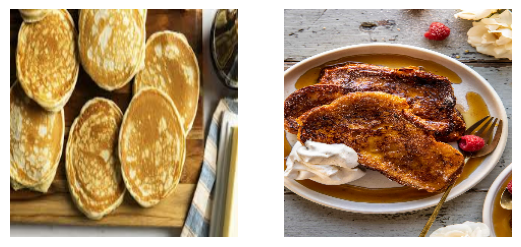

In [20]:
plt.figure(figsize=(10, 6))

for batch in mini_demo_dataset:
    for i, img in enumerate(batch):
        if i >= 2: break
        ax = plt.subplot(1, 3, i + 1)
        ax.imshow(img.numpy().astype("uint8"))
        ax.axis("off")
    break


In [21]:
predictions = best_network.predict(mini_demo_dataset)
for p in predictions:
    if p > 0.5:
        print(f"{p} : Predicted class: Pancake")
    else:
        print(f"{p} : Predicted class: French Toast")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 143ms/step
[0.7096245] : Predicted class: Pancake
[0.00278528] : Predicted class: French Toast


The pancakes, although extremely pancake looking, have been classified as french toast. This is beacuse french toast is more likely to be photographed next to each other, whereas pancakes are usually stacked. When a picture of pancakes next to each other appears, the model incorrectly assumes they are french toast. This is a big weakness of the model and shows it has not correctly learned the shape of each food, but its position in the photograph.

The french toast on the right hand side is often mis-categorised as pancakes. This however is less concerning as the picture of french toast is very irregular in shape and not a good representation of what french toast looks like. The confusion of the model here is therefore understandable. With more irregular examples like this in the training set, the model would correct this mistake

# IN CONCLUSION:

The model is very good at classifying with only two noted weaknesses. It has not learned any of the common shortcuts but instead developed a strong understanding of each class in order to classify correctly. I believe with more training examples of a more diverse nature, it would further increase the accuracy and remove its current weaknesses.